<a href="https://colab.research.google.com/github/seoyeon3/AB-test/blob/main/ab_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Description

This project evaluates the performance of test and control groups across key funnel metrics: impressions, clicks, purchases, and revenue.  





# Contents


1. [Data Load SQL](#data-load-sql)
2. [AA Test: One Sample T-test](#aa-test-one-sample-t-test)
3. [Initial Two Sample T-test](#initial-two-sample-t-test)
4. [Create Table for Tableau](#create-table-for-tableau)
5. [Segmented A/B Test Dashboard](#segmented-ab-test-dashboard)
6. [Segment-Level Insight](#segment-level-insight)
7. [Business Recommendation](#business-recommendation)

# Setting

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
import os
os.chdir('gdrive/MyDrive/AB_testing/data')
!ls

aa-example.csv	duckdb.db  user-event.csv  user-metadata.csv  user-variant.csv


In [ ]:
!pip install --quiet duckdb
!pip install --quiet jupysql
!pip install --quiet duckdb-engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.8/192.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.0/264.0 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.2 MB/s eta 0:00:00


In [ ]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#%load_ext sql
%reload_ext sql

In [ ]:
%sql duckdb:///duckdb.db

Connecting to 'duckdb:///duckdb.db'

<a name="data-load-sql"></a>
# **Data Load (SQL)**
* Load the required files from cloud data storage
* Database Setup: Creating Schemas and Tables for analysis

In [ ]:
%%sql

create schema if not exists raw_data;
create schema if not exists analytics;

Running query in 'duckdb:///duckdb.db'

Count


In [ ]:
%%sql

create table if not exists raw_data.user_event(
  user_id int,
  datestamp timestamp,
  item_id int,
  clicked int,
  purchased int,
  paidamount int
);

Running query in 'duckdb:///duckdb.db'

Count


In [ ]:
%%sql

create table if not exists raw_data.user_variant (
  user_id int,
  variant_id varchar(32)
);

Running query in 'duckdb:///duckdb.db'

Count


In [ ]:
%%sql

create table if not exists raw_data.user_metadata(
  user_id int,
  age varchar(16),
  country varchar(32)
);

Running query in 'duckdb:///duckdb.db'

Count


In [ ]:
%%sql

create table if not exists raw_data.aa_example(
  user_id int,
  date date,
  job_position_id int,
  clicked int,
  checkedout int,
  applied int
);

Running query in 'duckdb:///duckdb.db'

Count


In [ ]:
%%sql

SELECT table_schema, table_name
FROM information_schema.tables
WHERE table_schema IN ('raw_data', 'analytics');

Running query in 'duckdb:///duckdb.db'

table_schema,table_name
analytics,analytics_variant_user_daily
analytics,variant_daily_session
analytics,variant_daily_sessions
raw_data,aa_example
raw_data,user_event
raw_data,user_metadata
raw_data,user_variant


In [ ]:
%config SqlMagic.autopandas = True
%config SqlMagic.feedback = False
%config SqlMagic.displaycon = False

In [ ]:
!wget https://s3-geospatial.s3.us-west-2.amazonaws.com/user-metadata.csv
!wget https://s3-geospatial.s3.us-west-2.amazonaws.com/user-event.csv
!wget https://s3-geospatial.s3.us-west-2.amazonaws.com/user-variant.csv
!wget https://s3-geospatial.s3.us-west-2.amazonaws.com/aa-example.csv

In [ ]:
%%sql

INSERT INTO raw_data.user_metadata SELECT * FROM 'user-metadata.csv';
INSERT INTO raw_data.user_variant SELECT * FROM 'user-variant.csv';
INSERT INTO raw_data.user_event SELECT * FROM 'user-event.csv';
INSERT INTO raw_data.aa_example SELECT * FROM 'aa-example.csv';

,Success


In [ ]:
%%sql

select * from raw_data.user_event limit 10;

,user_id,datestamp,item_id,clicked,purchased,paidamount
0,91139,2019-01-13,34,0,0,0
1,91139,2019-01-13,77,0,0,0
2,91139,2019-01-13,17,0,0,0
3,40135,2019-01-14,54,1,0,0
4,40135,2019-01-14,2,0,0,0
5,40135,2019-01-14,96,0,0,0
6,40135,2019-01-14,23,0,0,0
7,40135,2019-01-14,12,1,0,0
8,40135,2019-01-14,14,0,0,0
9,40135,2019-01-14,68,0,0,0


In [ ]:
%%sql
select * from raw_data.user_variant limit 10;

,user_id,variant_id
0,0,test
1,1,test
2,2,control
3,3,test
4,4,control
5,5,test
6,6,control
7,7,test
8,8,control
9,9,control


In [ ]:
%%sql
select * from raw_data.user_metadata limit 10;

,user_id,age,gender
0,0,50-up,female
1,1,50-up,female
2,2,0-19,female
3,3,50-up,female
4,4,0-19,male
5,5,0-19,female
6,6,0-19,undefined
7,7,50-up,female
8,8,50-up,male
9,9,0-19,male


In [ ]:
%%sql
select * from raw_data.aa_example limit 10;

,user_id,date,job_position_id,clicked,checkedout,applied
0,6810,2022-01-03,4891,1,1,0
1,117686,2022-01-03,8882,1,1,1
2,117686,2022-01-03,9006,1,1,1
3,316741,2022-01-03,8331,1,1,1
4,380002,2022-01-03,2385,1,1,1
5,117686,2022-01-03,8683,1,1,1
6,374410,2022-01-03,9014,1,1,1
7,285735,2022-01-03,1458,1,1,0
8,380002,2022-01-03,7088,1,1,1
9,395070,2022-01-03,5482,1,1,1


### create variant_daily_session table under analytics schema

* Interests: Total Impression, Total Click, Total Purchase, Total Revenue

In [ ]:
%%sql
select * from raw_data.user_variant limit 10;

,user_id,variant_id
0,0,test
1,1,test
2,2,control
3,3,test
4,4,control
5,5,test
6,6,control
7,7,test
8,8,control
9,9,control


In [ ]:
%%sql

create table analytics.variant_daily_sessions as
select
  uv.variant_id,
  ue.user_id,
  ue.datestamp,
  count(distinct ue.item_id) as num_of_items,
  sum(ue.clicked) as num_of_clicks,
  sum(ue.purchased) as num_of_purchases,
  sum(ue.paidamount) as revenue
from raw_data.user_variant uv
join raw_data.user_event ue
on uv.user_id = ue.user_id
group by 1,2,3;


In [ ]:
%%sql

select *
from analytics.variant_daily_sessions
limit 100;

,variant_id,user_id,datestamp,num_of_items,num_of_clicks,num_of_purchases,revenue
0,control,40135,2019-01-12,18,8.0,2.0,68.0
1,test,89370,2019-01-16,2,0.0,0.0,0.0
2,test,89370,2019-01-15,2,0.0,0.0,0.0
3,test,89371,2019-01-13,7,2.0,0.0,0.0
4,control,89376,2019-01-13,4,1.0,1.0,11.0
...,...,...,...,...,...,...,...
95,control,46863,2019-01-11,2,0.0,0.0,0.0
96,test,46862,2019-01-16,25,5.0,0.0,0.0
97,test,46862,2019-01-13,15,5.0,1.0,23.0
98,test,46862,2019-01-14,3,1.0,0.0,0.0


<a name="aa-test-one-sample-t-test"></a>
# **AA test: One Sample T-test for 50:50 Split (Python)**

Hash Split Sanity Check

- Check whether the random assignment / hash-based split was close to a 50:50 ratio.
- Test whether `variant_id` was evenly split between 0 and 1.
- Null hypothesis: the mean of `variant_id` is 0.5.


In [ ]:
# Assign variant id
df = %sql
select MOD(HASH(user_id), 2) as variant_id
from (
    select distinct user_id from raw_data.aa_example
)

124632

In [ ]:
df.head()

,variant_id
0,1
1,1
2,0
3,1
4,0


In [ ]:
from scipy.stats import ttest_1samp
t_statistic, p_value = ttest_1samp(df['variant_id'],0.5)

print(f't statistic: {t_statistic}\np-value: {p_value}')

t statistic: -1.525918598586898
p-value: 0.12710680293489504


* The A/A sanity check showed no statistically significant deviation from a 50:50 split, with the t-statistic within ±1.96 and the p-value greater than 0.05.

* This indicates that the random assignment mechanism produced approximately balanced test and control groups before the A/B test analysis.

### Proportion z test

$Z-score = (p-0.5)/\sqrt\frac{p(1-p)}{N}$

In [ ]:
# Manual way
import math

def compute_zscore(n_test, n_ctrl, p_ctrl=0.5):
    n = n_test + n_ctrl
    p = n_test/n
    s_test = math.sqrt(p*(1.0-p)/n)
    z_score = (p-p_ctrl)/s_test

    return z_score

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

count_1 = (df['variant_id'] == 1).sum()
n = len(df)

z_stat, p_value = proportions_ztest(
    count=count_1,
    nobs=n,
    value=0.5
)

print(z_stat, p_value)

-1.526103547208702 0.1269840788155945


<a name="initial-two-sample-t-test"></a>
# **Initial Two Sample T-test (Python)**
* Test the differences between the test and control groups for Impression, Click, Purchase, and Revenue.

In [ ]:
variant_daily_sessions = %sql SELECT * FROM analytics.variant_daily_sessions
variant_daily_sessions.head()

,variant_id,user_id,datestamp,num_of_items,num_of_clicks,num_of_purchases,revenue
0,control,40135,2019-01-12,18,8.0,2.0,68.0
1,test,89370,2019-01-16,2,0.0,0.0,0.0
2,test,89370,2019-01-15,2,0.0,0.0,0.0
3,test,89371,2019-01-13,7,2.0,0.0,0.0
4,control,89376,2019-01-13,4,1.0,1.0,11.0


In [ ]:
variant_daily_sessions.isnull().sum()

,0
variant_id,0
user_id,0
datestamp,0
num_of_items,0
num_of_clicks,0
num_of_purchases,0
revenue,0


In [ ]:
variant_daily_sessions.groupby('variant_id').size()

,0
variant_id,
control,82526
test,83116


In [ ]:
variant_daily_sessions.groupby('variant_id')['revenue'].mean()

,revenue
variant_id,
control,5.590990
test,5.570203


In [ ]:
from scipy.stats import ttest_ind

t_statistic, p_value = ttest_ind(
    variant_daily_sessions[variant_daily_sessions['variant_id']=='test']['revenue'],
    variant_daily_sessions[variant_daily_sessions['variant_id']=='control']['revenue']
)
print('Revenue t-test')
print('t-statistic',t_statistic)
print('p-value',p_value)

Revenue t-test
t-statistic -0.30893666944286313
p-value 0.7573700906452349


In [ ]:
# Impression
from scipy.stats import ttest_ind

t_statistic, p_value = ttest_ind(
    variant_daily_sessions[variant_daily_sessions['variant_id']=='test']['num_of_items'],
    variant_daily_sessions[variant_daily_sessions['variant_id']=='control']['num_of_items']
)

print('Impression t-test')
print('t-statistic',t_statistic)
print('p-value',p_value)

Impression t-test
t-statistic 1.3787392352028343
p-value 0.16797702966025999


In [ ]:
# Click
from scipy.stats import ttest_ind

t_statistic, p_value = ttest_ind(
    variant_daily_sessions[variant_daily_sessions['variant_id']=='test']['num_of_clicks'],
    variant_daily_sessions[variant_daily_sessions['variant_id']=='control']['num_of_clicks']
)

print('Click t-test')
print('t-statistic',t_statistic)
print('p-value',p_value)

Click t-test
t-statistic 1.2378079313561117
p-value 0.2157890413600264


In [ ]:
# Purchase
from scipy.stats import ttest_ind

t_statistic, p_value = ttest_ind(
    variant_daily_sessions[variant_daily_sessions['variant_id']=='test']['num_of_purchases'],
    variant_daily_sessions[variant_daily_sessions['variant_id']=='control']['num_of_purchases']
)

print('Purchase t-test')
print('t-statistic',t_statistic)
print('p-value',p_value)

Purchase t-test
t-statistic -0.6220642246344509
p-value 0.5339004941211412


* Across all four funnel metrics (Impression, Click, Purchase, and Revenue), the t-statistics were within the range of -1.96 to 1.96, and all p-values were greater than 0.05.  
* This indicates that there was no statistically significant difference between the test and control groups at the overall level.

### Manual t-score calculation

The t-score was calculated manually using the formula below:

$t = \frac{\bar{x}_a - \bar{x}_b}{\sqrt{\frac{s_a^2}{n_a} + \frac{s_b^2}{n_b}}}$

$\text{where,} \,  var_a = E(X_a^2)-E(X_a)^2, \text{and } var_b = E(X_b^2)-E(X_b)^2 $

The required values were calculated separately for each group:

- `mean_a` and `mean_b`: group means
- `n_a` and `n_b`: group sizes
- `square_a` and `square_b`: mean of squared values

The group variances were calculated as:

- `var_b = square_b - mean_b * mean_b`
- `var_a = square_a - mean_a * mean_a`

Finally, the t-score was calculated as:

```python
(mean_b - mean_a) / math.sqrt(var_b / n_b + var_a / n_a)

In [ ]:
def compute_z_score_hand(df, field_name):
  a = df[df["variant_id"]=="control"][field_name].to_numpy()
  b = df[df["variant_id"]=="test"][field_name].to_numpy()

  n_a = len(a)
  n_b = len(b)

  a_sum = 0
  aa = 0
  b_sum = 0
  bb = 0

  for i in a:
    a_sum += i
    aa += i*i

  for i in b:
    b_sum += i
    bb += i*i

  mean_a = a_sum/n_a
  mean_b = b_sum/n_b

  var_a = aa/n_a - mean_a*mean_a
  var_b = bb/n_b - mean_b*mean_b

  t_score = (mean_b - mean_a)/math.sqrt(var_a/n_a+var_b/n_b)

  return t_score

<a name="create-table-for-tableau"></a>
# **Create table for Tableau (SQL)**

* Create an aggregated table for each funnel stage for Tableau analysis.

* Prepare metrics such as count, sum, and sum of squares by segment.



1. Created `analytics.analytics_variant_user_daily`

2. Created `analytics.olap_cube`


3. Exported the contents of `analytics.olap_cube` as `sessions_hypercube.csv`

4. Downloaded `sessions_hypercube.csv` for Tableau dashboard development

In [ ]:
%%sql

DROP TABLE IF EXISTS analytics.analytics_variant_user_daily;
CREATE TABLE analytics.analytics_variant_user_daily AS
SELECT
  variant_id,
  ue.user_id,
  datestamp, age, gender,
  COUNT(DISTINCT item_id) num_of_items,                             -- 총 impression
  COUNT(DISTINCT CASE WHEN clicked THEN item_id END) num_of_clicks, -- 총 click
  SUM(purchased) num_of_purchases,                                  -- 총 purchase
  SUM(paidamount) revenue                                           -- 총 revenue
FROM raw_data.user_event ue
JOIN raw_data.user_variant uv ON ue.user_id = uv.user_id
JOIN raw_data.user_metadata um ON uv.user_id = um.user_id
GROUP by 1, 2, 3, 4, 5;

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Success


In [ ]:
%%sql

select * from analytics.analytics_variant_user_daily limit 10;

,variant_id,user_id,datestamp,age,gender,num_of_items,num_of_clicks,num_of_purchases,revenue
0,control,32243,2019-01-15,50-up,female,4,2,0.0,0.0
1,control,32240,2019-01-16,0-19,female,5,2,8.0,88.0
2,control,32241,2019-01-15,0-19,male,3,1,0.0,0.0
3,control,55645,2019-01-15,50-up,male,3,1,0.0,0.0
4,control,32244,2019-01-11,0-19,male,2,0,0.0,0.0
5,control,32245,2019-01-16,0-19,undefined,1,0,0.0,0.0
6,test,55649,2019-01-11,50-up,female,3,1,0.0,0.0
7,test,55649,2019-01-12,50-up,female,4,0,0.0,0.0
8,control,32248,2019-01-14,50-up,female,3,2,0.0,0.0
9,control,98128,2019-01-13,0-19,male,3,0,0.0,0.0


In [ ]:
%%sql
drop table if exists analytics.olap_cube;
create table analytics.olap_cube as
select
  datestamp, variant_id, age, gender,
  'impression' as category,
  count(1) as n,
  sum(num_of_items) as sum,
  sum(num_of_items * num_of_items) as sum2
from analytics.analytics_variant_user_daily
group by 1,2,3,4

union

select
  datestamp, variant_id, age, gender,
  'click' as category,
  count(1) as n,
  sum(num_of_clicks) as sum,
  sum(num_of_clicks * num_of_clicks) as sum2
from analytics.analytics_variant_user_daily
group by 1,2,3,4

union

select
  datestamp, variant_id, age, gender,
  'purchase' as category,
  count(1) as n,
  sum(num_of_purchases) as sum,
  sum(num_of_purchases * num_of_purchases) as sum2
from analytics.analytics_variant_user_daily
group by 1,2,3,4

union

select
  datestamp, variant_id, age, gender,
  'revenue' as category,
  count(1) as n,
  sum(revenue) as sum,
  sum(revenue * revenue) as sum2
from analytics.analytics_variant_user_daily
group by 1,2,3,4;


,Success


In [ ]:
%%sql

select * from analytics.olap_cube limit 10;

,datestamp,variant_id,age,gender,category,n,sum,sum2
0,2019-01-15,control,50-up,female,revenue,1536,33832.0,7275968.0
1,2019-01-15,control,50-up,male,revenue,1534,31584.0,8252032.0
2,2019-01-11,control,0-19,male,revenue,1910,35808.0,8156800.0
3,2019-01-11,test,50-up,female,revenue,1503,38368.0,9963776.0
4,2019-01-12,test,50-up,female,revenue,1620,40832.0,9755264.0
5,2019-01-17,control,0-19,male,revenue,1996,39104.0,10144000.0
6,2019-01-12,test,50-up,male,revenue,1583,32136.0,7310912.0
7,2019-01-14,test,20-49,female,revenue,1310,138384.0,48804736.0
8,2019-01-11,test,0-19,undefined,revenue,916,22376.0,5399872.0
9,2019-01-13,test,0-19,female,revenue,1891,45400.0,11609024.0


In [ ]:
%%sql
copy analytics.olap_cube to 'sessions_hypercube.csv'

,Success


In [ ]:
!ls -tl

total 75064
-rw------- 1 root root    32479 May 30 00:19 sessions_hypercube.csv
-rw------- 1 root root    38785 May 30 00:18 duckdb.db.wal
-rw------- 1 root root 19148800 May 30 00:17 duckdb.db
-rw------- 1 root root   620269 Jun 18  2024 aa-example.csv
-rw------- 1 root root   620269 Jun 18  2024 aa-example.csv.1
-rw------- 1 root root  1238510 Jan 15  2023 user-variant.csv
-rw------- 1 root root  1238510 Jan 15  2023 user-variant.csv.1
-rw------- 1 root root  1820607 Jan 15  2023 user-metadata.csv
-rw------- 1 root root  1820607 Jan 15  2023 user-metadata.csv.1
-rw------- 1 root root 25142284 Jan 15  2023 user-event.csv
-rw------- 1 root root 25142284 Jan 15  2023 user-event.csv.1


In [ ]:
from google.colab import files
files.download('sessions_hypercube.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<a name="segmented-ab-test-dashboard"></a>
# **Segmented A/B test Dashboard (Tableau)**

[Tableau Dashboard](https://public.tableau.com/app/profile/seoyeon.park.ds/viz/ABTestingPerformanceDashboard/KPIAnalysisABTestingReport)

<a name="segment-level-insight"></a>
# **Segment-Level Insight**

* The strongest insight is that the test variant produced different responses across age groups within female users.

* In the 0–19 female segment, Impression was not substantially different from the control group, but Click, Purchase, and Revenue all increased. This suggests that the improvement was not driven simply by higher exposure, but by a stronger user response to the test variant.

* In contrast, in the 20–49 female segment, Impression was not substantially different from the control group, and there was no major negative change up to the Click stage, but Purchase and Revenue decreased. This suggests that the test variant may have negatively affected purchase conversion or revenue generation for female users in this age group.

* For the 50+ segment, no statistically meaningful change was observed.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
lift_df = pd.DataFrame({
    "age_group": ["0-19", "0-19", "0-19", "20-49", "20-49", "20-49"],
    "metric": ["Click", "Purchase", "Revenue", "Click", "Purchase", "Revenue"],
    "lift_percent": [4.99, 7.03, 8.25, -1.39, -4.05, -5.28],
    "t_statistic": [3.170, 1.975, 2.00, -1.172, -1.990, -2.30]
})

lift_df

# pivot_df = lift_df.pivot(index="metric", columns="age_group", values="lift_percent")

,age_group,metric,lift_percent,t_statistic
0,0-19,Click,4.99,3.170
1,0-19,Purchase,7.03,1.975
2,0-19,Revenue,8.25,2.000
3,20-49,Click,-1.39,-1.172
4,20-49,Purchase,-4.05,-1.990
5,20-49,Revenue,-5.28,-2.300


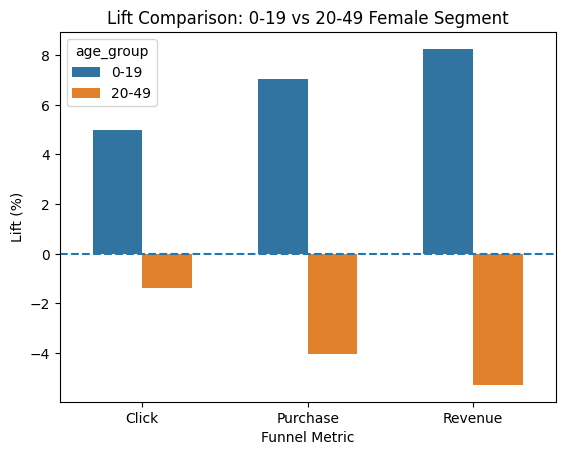

In [ ]:
plt.figsize=(12, 6)
sns.barplot(data=lift_df, x="metric", y="lift_percent", hue="age_group", width=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Funnel Metric")
plt.ylabel("Lift (%)")
plt.title("Lift Comparison: 0-19 vs 20-49 Female Segment")
plt.xticks(rotation=0)
plt.show()

<a name="business-recommendation"></a>
# **Business Recommendation**

* Therefore, instead of rolling out the test variant to all users immediately, a limited rollout or further validation could be considered for the 0–19 female segment, where positive effects were observed.

* In contrast, for the 20–49 female segment, the causes of the decrease in Purchase and Revenue should be investigated further, and applying the same variant to this segment should be postponed.